# Exp09b — M15 Execution Feasibility (HOLDOUT OOS)

### Prior Chain

| Exp | Result | Key finding |
|-----|--------|-------------|
| 08a | NO-GO  | FQR=1.124 [PASS] but gap=66.8x [FAIL] — M1 drift microscopic |
| 09a | GO     | Gap→1.4x at M15. U-shape: P(cont@1c)=42.6%→56.1%@h5. Drift 14.7x superlinear |

### Bounded Claim Statement

> This experiment tests whether the wick-absorption edge observed at M15 (Exp09a TRAIN)
> survives on **out-of-sample holdout** and whether **fill-adjusted E_net > 0** after real costs.
>
> Strictly bounded: `{OHLCV, M15, EER=Low+Vol=Low, maker entry, h=5 exit}` → E_net > 0 OOS?

### ⚠️ Winner's Curse Warning

Low+Low was selected after exploring multiple bins (9 bins) and multiple timeframes.
Expected upward bias in train E[ret] is non-zero.
This is why holdout is mandatory AND why **Jackknife LOO (Cell 10)** is required.
A positive holdout E_net without LOO stability is not sufficient for GO.

### Design Decisions

| Decision | Value | Rationale |
|----------|-------|-----------|
| Primary horizon | **h=5** (75 min) | Strongest signal in 09a |
| Fill models | **C and D** (B = reference) | B trivially 100% fill → FQR=1.0 algebraically |
| Data | **HOLDOUT ONLY** | All 09a was TRAIN |
| Thresholds | **FROZEN from 09a** | No recalibration = no lookahead |
| Bootstrap blocks | **{3, 5, 10}** | M15 alpha half-life ≈ 3–5c (not 20) |
| GO criteria | E_net[C@3c, mk+tk] > 0 **AND** CI_lower > 0 **AND** LOO stable | All three required |


In [1]:
import hashlib, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

REPO_ROOT  = Path('C:/Users/Lenovo/Documents/TRADING-BOT')
DATA_FILE  = REPO_ROOT / 'data' / 'raw' / 'BTCUSDT_M1.csv'
OUTPUT_DIR = REPO_ROOT / 'research' / 'experiments' / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEP = '=' * 68

# ── FROZEN from Exp09a (SPEC_HASH 89f1a4e54b3a) ─────────────────────────────
ATR_THRESH_M15        = 1.7027
EER_LOW_M15           = 0.4167
VOL_LOW_PCT_M15       = 0.50
SPLIT_DATE            = pd.Timestamp('2026-03-29', tz='UTC')
ATR_WINDOW_M15        = 20
PERCENTILE_WINDOW_M15 = 500
FILL_EPSILON          = 0.0001

# ── 09b config ───────────────────────────────────────────────────────────────
PRIMARY_H    = 5            # optimal horizon from 09a U-shape
PATH_H       = 10           # max horizon for path shape analysis
FWD_HORIZONS = [1, 3, 5]   # horizons for cont_ret
FILL_HORIZONS= [1, 3]      # fill detection windows (< PRIMARY_H)
BLOCK_SIZES  = [3, 5, 10]  # bootstrap block sensitivity (M15 half-life ≈ 3-5c, NOT 20)
N_BOOTSTRAP  = 2000

# Cost model
MAKER_REBATE  = 0.0002   # +0.02%
TAKER_FEE     = 0.0004   # -0.04%
NET_COST_MT   = TAKER_FEE - MAKER_REBATE   # maker_in + taker_out = 0.02%
NET_COST_MM   = -(2 * MAKER_REBATE)        # maker_in + maker_out = -0.04% (full rebate)

# GO thresholds
FQR_GO      = 0.70
ENET_GO     = 0.0
CI_LOWER_GO = 0.0
LOO_STABLE  = 0.70   # P(E_net_LOO > 0) must exceed this to claim stability

# 09a reference
REF_09A = {
    'spec_hash'   : '89f1a4e54b3a',
    'n_train_LL'  : 61,
    'fqr_B3c'     : 1.000,
    'fqr_C3c'     : 1.223,
    'gap_raw_3c'  : 1.4,
    'pcont_h1'    : 42.6,
    'pcont_h5'    : 56.1,
    'drift_3c_pct': -0.05847,
}

SPEC = {
    'version'     : '09b-v1',
    'prior'       : f'Exp09a-{REF_09A["spec_hash"]}',
    'objective'   : 'execution_feasibility_holdout',
    'primary_h'   : PRIMARY_H,
    'atr_thresh'  : ATR_THRESH_M15,
    'eer_low'     : EER_LOW_M15,
    'block_sizes' : BLOCK_SIZES,
}
SPEC_HASH = hashlib.sha256(json.dumps(SPEC, sort_keys=True).encode()).hexdigest()[:12]

print('Cell 2 OK — Exp09b: M15 Execution Feasibility (HOLDOUT OOS)')
print(f'SPEC_HASH: {SPEC_HASH}')
print(f'Primary horizon: h={PRIMARY_H} ({PRIMARY_H*15} min)')
print(f'Fill models: C (touch-through) + D (close-through)  [B = reference]')
print(f'Bootstrap block sizes: {BLOCK_SIZES}  (M15-appropriate; NOT block=20 from M1 experiments)')
print(f'Costs: maker+taker={NET_COST_MT*100:.2f}%  maker+maker={NET_COST_MM*100:+.2f}%')
print(f'GO criteria: E_net>0 AND CI_lower>0 AND P(LOO>0)>{LOO_STABLE}')


Cell 2 OK — Exp09b: M15 Execution Feasibility (HOLDOUT OOS)
SPEC_HASH: c40753cfb893
Primary horizon: h=5 (75 min)
Fill models: C (touch-through) + D (close-through)  [B = reference]
Bootstrap block sizes: [3, 5, 10]  (M15-appropriate; NOT block=20 from M1 experiments)
Costs: maker+taker=0.02%  maker+maker=-0.04%
GO criteria: E_net>0 AND CI_lower>0 AND P(LOO>0)>0.7


In [2]:
# Load M1 → resample M15 → features → HOLDOUT ONLY
df_m1 = pd.read_csv(DATA_FILE)
df_m1['open_time'] = pd.to_datetime(df_m1['open_time'], unit='ms', utc=True)
df_m1 = df_m1.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_m1[col] = df_m1[col].astype(float)

print(f'M1: {len(df_m1):,} candles | {df_m1["open_time"].iloc[0].date()} -> {df_m1["open_time"].iloc[-1].date()}')

df_full = (df_m1.set_index('open_time')
           .resample('15min')
           .agg({'open':'first','high':'max','low':'min','close':'last','volume':'sum'})
           .dropna(subset=['open','close'])
           .reset_index())
df_full['date'] = df_full['open_time'].dt.date
print(f'M15 full: {len(df_full):,} candles')

# ATR + EER + vol_pct (must run on full series for rolling integrity)
prev_close         = df_full['close'].shift(1)
df_full['tr']      = np.maximum(df_full['high'] - df_full['low'],
                     np.maximum((df_full['high'] - prev_close).abs(),
                                (df_full['low']  - prev_close).abs()))
df_full['atr']     = df_full['tr'].rolling(ATR_WINDOW_M15, min_periods=ATR_WINDOW_M15//2).mean()
df_full['tr_ratio']= df_full['tr'] / df_full['atr']
body               = (df_full['close'] - df_full['open']).abs()
rng                = (df_full['high'] - df_full['low']).replace(0, np.nan)
df_full['eer']     = (body / rng).clip(0, 1)
df_full['dir_sign']= np.where(df_full['close'] >= df_full['open'], 1.0, -1.0)
df_full['vol_pct'] = df_full['volume'].rolling(PERCENTILE_WINDOW_M15, min_periods=50).rank(pct=True)

# Forward closes up to PATH_H (needed for path shape + cont_ret)
for h in range(1, PATH_H + 1):
    df_full[f'fwd_c{h}'] = df_full.groupby('date')['close'].shift(-h)

# Fill detection features
for h in FILL_HORIZONS:
    df_full[f'fwd_min_low_{h}']   = df_full['low'].rolling(h).min().shift(-h)
    df_full[f'fwd_max_high_{h}']  = df_full['high'].rolling(h).max().shift(-h)
    df_full[f'fwd_close_min_{h}'] = df_full['close'].rolling(h).min().shift(-h)
    df_full[f'fwd_close_max_{h}'] = df_full['close'].rolling(h).max().shift(-h)

# Cont returns for all horizons 1..PATH_H
for h in range(1, PATH_H + 1):
    df_full[f'cont_{h}c'] = (df_full[f'fwd_c{h}'] - df_full['close']) * df_full['dir_sign'] / df_full['close']

# Split
df_full['split']  = np.where(df_full['open_time'] < SPLIT_DATE, 'train', 'holdout')
holdout           = df_full[df_full['split'] == 'holdout'].copy().reset_index(drop=True)
train_ref         = df_full[df_full['split'] == 'train']

print(f'Train (reference only): {len(train_ref):,}  |  Holdout (09b): {len(holdout):,} M15 candles')
print(f'Holdout period: {holdout["open_time"].iloc[0].date()} -> {holdout["open_time"].iloc[-1].date()}')
print('Cell 3 OK')


M1: 518,401 candles | 2025-05-29 -> 2026-05-24
M15 full: 34,561 candles
Train (reference only): 29,096  |  Holdout (09b): 5,465 M15 candles
Holdout period: 2026-03-29 -> 2026-05-24
Cell 3 OK


In [3]:
# Verify frozen thresholds on holdout — no recalibration
print(SEP)
print('CELL 4 - FROZEN THRESHOLD VERIFICATION')
print(f'FROZEN: ATR_THRESH={ATR_THRESH_M15:.4f} (09a P90)  EER_LOW={EER_LOW_M15:.4f} (09a P40)')
print(SEP)

p_atr = (holdout['tr_ratio'] > ATR_THRESH_M15).mean()
p_eer = (holdout['eer'] < EER_LOW_M15).mean()
atr_p90_h = holdout['tr_ratio'].quantile(0.90)
eer_p40_h = holdout['eer'].quantile(0.40)

print(f'\n  Holdout P(TR/ATR > {ATR_THRESH_M15:.4f}): {p_atr*100:.1f}%  (target ~10% | holdout P90={atr_p90_h:.3f})')
print(f'  Holdout P(EER < {EER_LOW_M15:.4f}):       {p_eer*100:.1f}%  (target ~40% | holdout P40={eer_p40_h:.3f})')

atr_shift = abs(atr_p90_h - ATR_THRESH_M15) / ATR_THRESH_M15
eer_shift  = abs(eer_p40_h - EER_LOW_M15)   / EER_LOW_M15
print()
print(f'  ATR threshold stability: {atr_shift*100:.0f}% shift  -> {"STABLE" if atr_shift<0.15 else "WARN: regime shift possible"}')
print(f'  EER threshold stability: {eer_shift*100:.0f}% shift  -> {"STABLE" if eer_shift<0.15 else "WARN: regime shift possible"}')
print()
print('  Decision: NEVER recalibrate on holdout. Note any instability in verdict.')
print('Cell 4 OK')


CELL 4 - FROZEN THRESHOLD VERIFICATION
FROZEN: ATR_THRESH=1.7027 (09a P90)  EER_LOW=0.4167 (09a P40)

  Holdout P(TR/ATR > 1.7027): 10.2%  (target ~10% | holdout P90=1.711)
  Holdout P(EER < 0.4167):       42.5%  (target ~40% | holdout P40=0.393)

  ATR threshold stability: 0% shift  -> STABLE
  EER threshold stability: 6% shift  -> STABLE

  Decision: NEVER recalibrate on holdout. Note any instability in verdict.
Cell 4 OK


In [4]:
# Signal + fill flags (B, C, D) on holdout
holdout['eer_bucket'] = pd.cut(holdout['eer'],
    bins=[-0.01, EER_LOW_M15, 0.65, 1.01], labels=['Low','Med','High'])
holdout['vol_bucket'] = pd.cut(holdout['vol_pct'],
    bins=[-0.01, VOL_LOW_PCT_M15, 0.90, 1.01], labels=['Low','Med','High'])
holdout['bin']       = holdout['eer_bucket'].astype(str) + '+' + holdout['vol_bucket'].astype(str)
holdout['is_burst']  = holdout['tr_ratio'] > ATR_THRESH_M15
holdout['is_signal'] = holdout['is_burst'] & (holdout['bin'] == 'Low+Low')

def _fill_flags(subset):
    lm  = (subset['dir_sign'] == 1.0).values
    sm  = (subset['dir_sign'] == -1.0).values
    cl0 = subset['close'].values
    eps = cl0 * FILL_EPSILON
    for h in FILL_HORIZONS:
        minl = subset[f'fwd_min_low_{h}'].values
        maxh = subset[f'fwd_max_high_{h}'].values
        cmin = subset[f'fwd_close_min_{h}'].values
        cmax = subset[f'fwd_close_max_{h}'].values
        subset[f'fill_B_{h}c'] = (lm & (minl <= cl0))       | (sm & (maxh >= cl0))
        subset[f'fill_C_{h}c'] = (lm & (minl < cl0 - eps))  | (sm & (maxh > cl0 + eps))
        subset[f'fill_D_{h}c'] = (lm & (cmin < cl0))        | (sm & (cmax > cl0))

sig_all  = holdout[holdout['is_burst']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
sig_prim = holdout[holdout['is_signal']].dropna(subset=[f'cont_{PRIMARY_H}c']).copy().reset_index(drop=True)
_fill_flags(sig_all)
_fill_flags(sig_prim)

n_burst = holdout['is_burst'].sum()
n_sig   = holdout['is_signal'].sum()
print(f'Holdout burst events: {n_burst}  ({n_burst/len(holdout)*100:.1f}%)')
print(f'EER=Low+Vol=Low (primary bin): n_signal={n_sig}  ->  sig_prim (after dropna): {len(sig_prim)}')
print()
if len(sig_prim) < 5:
    print('CRITICAL: n < 5. Results undefined. Expand historical data before proceeding.')
    raise SystemExit('Insufficient holdout events.')
elif len(sig_prim) < 15:
    print(f'WARN: n={len(sig_prim)}. Jackknife LOO is mandatory (Cell 10). CI will be very wide.')
elif len(sig_prim) < 30:
    print(f'CAUTION: n={len(sig_prim)}. Report with explicit uncertainty.')
else:
    print(f'OK: n={len(sig_prim)}')
print()
print('Bin counts (holdout burst events):')
for b, cnt in holdout[holdout['is_burst']]['bin'].value_counts().sort_index().items():
    flag = '  <- PRIMARY' if b == 'Low+Low' else ''
    print(f'  {b}: n={cnt}{flag}')
print('Cell 5 OK')


Holdout burst events: 559  (10.2%)
EER=Low+Vol=Low (primary bin): n_signal=12  ->  sig_prim (after dropna): 12

WARN: n=12. Jackknife LOO is mandatory (Cell 10). CI will be very wide.

Bin counts (holdout burst events):
  High+High: n=121
  High+Low: n=35
  High+Med: n=110
  Low+High: n=66
  Low+Low: n=12  <- PRIMARY
  Low+Med: n=58
  Med+High: n=75
  Med+Low: n=16
  Med+Med: n=66
Cell 5 OK


In [5]:
# Alpha half-life on holdout
print(SEP)
print(f'CELL 6 - ALPHA HALF-LIFE ON HOLDOUT  (primary h={PRIMARY_H})')
print(f'09a train: P(cont@1c)={REF_09A["pcont_h1"]:.1f}%  P(cont@5c)={REF_09A["pcont_h5"]:.1f}%  drift@3c={REF_09A["drift_3c_pct"]:+.5f}%')
print(SEP)

horizons_show = [h for h in range(1, PATH_H+1) if h <= 5 or h == PATH_H]

print(f'\n  {"H":>4}  {"P(cont) ALL":>12}  {"P(cont) LL":>12}  {"drift ALL%":>12}  {"drift LL%":>14}  {"09a ref"}')
pcont_list = []
drift_list = []

for h in range(1, PATH_H + 1):
    col = f'cont_{h}c'
    if col not in sig_prim.columns: continue
    pc_a = (sig_all[col].dropna() > 0).mean() * 100
    d_a  =  sig_all[col].mean() * 100
    pc_p = (sig_prim[col].dropna() > 0).mean() * 100 if len(sig_prim) >= 3 else np.nan
    d_p  =  sig_prim[col].mean() * 100               if len(sig_prim) >= 3 else np.nan
    pcont_list.append(pc_p)
    drift_list.append(d_p)
    if h in horizons_show:
        ref = ''
        if h == 1: ref = f'P(cont)={REF_09A["pcont_h1"]:.1f}% (09a)'
        if h == 5: ref = f'P(cont)={REF_09A["pcont_h5"]:.1f}% (09a)'
        print(f'  {h:>4}  {pc_a:>11.1f}%  {pc_p:>11.1f}%  {d_a:>+11.5f}%  {d_p:>+13.5f}%  {ref}')

print()
# U-shape check
pc_h1 = (sig_prim['cont_1c'].dropna() > 0).mean() * 100 if 'cont_1c' in sig_prim.columns else np.nan
pc_h5 = (sig_prim[f'cont_{PRIMARY_H}c'].dropna() > 0).mean() * 100
d_h5  =  sig_prim[f'cont_{PRIMARY_H}c'].mean() * 100

print(f'  U-shape holdout: P(cont@1c)={pc_h1:.1f}%  P(cont@5c)={pc_h5:.1f}%  delta={pc_h5-pc_h1:+.1f}pp')
print(f'  09a train:       P(cont@1c)={REF_09A["pcont_h1"]:.1f}%  P(cont@5c)={REF_09A["pcont_h5"]:.1f}%  delta={REF_09A["pcont_h5"]-REF_09A["pcont_h1"]:+.1f}pp')
print()
print(f'  Drift@h={PRIMARY_H} holdout: {d_h5:+.5f}%')
print(f'  E_net[raw, no fill adj]: drift - NET_COST_MT = {d_h5 - NET_COST_MT*100:+.5f}%')
if pc_h5 > 50:
    print(f'  U-shape direction PRESERVED in holdout (P(cont@5c)={pc_h5:.1f}% > 50%)')
else:
    print(f'  WARN: U-shape direction NOT preserved (P(cont@5c)={pc_h5:.1f}% < 50%)')
print('Cell 6 OK')


CELL 6 - ALPHA HALF-LIFE ON HOLDOUT  (primary h=5)
09a train: P(cont@1c)=42.6%  P(cont@5c)=56.1%  drift@3c=-0.05847%

     H   P(cont) ALL    P(cont) LL    drift ALL%       drift LL%  09a ref
     1         44.9%         58.3%     -0.00224%       +0.02007%  P(cont)=42.6% (09a)
     2         44.2%         41.7%     -0.00118%       +0.00909%  
     3         47.9%         41.7%     +0.01938%       -0.04400%  
     4         46.2%         50.0%     +0.00646%       -0.00232%  
     5         48.3%         58.3%     +0.00491%       +0.05647%  P(cont)=56.1% (09a)
    10         46.4%         54.5%     -0.01359%       +0.06093%  

  U-shape holdout: P(cont@1c)=58.3%  P(cont@5c)=58.3%  delta=+0.0pp
  09a train:       P(cont@1c)=42.6%  P(cont@5c)=56.1%  delta=+13.5pp

  Drift@h=5 holdout: +0.05647%
  E_net[raw, no fill adj]: drift - NET_COST_MT = +0.03647%
  U-shape direction PRESERVED in holdout (P(cont@5c)=58.3% > 50%)
Cell 6 OK


In [6]:
# FQR Analysis + Entry Quality Distribution
print(SEP)
print(f'CELL 7 - FQR + ENTRY QUALITY CONDITIONAL ON FILL  (h={PRIMARY_H} return)')
print(f'09a ref: FQR_B@3c=1.000 (trivial)  FQR_C@3c=1.223')
print('FQR > 1.0 = fills select better-than-unconditional events (anti-adverse selection)')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def bootstrap_fqr(ret_arr, fill_arr, n_boot=N_BOOTSTRAP, block=5):
    boot = []
    n    = len(ret_arr)
    n_blk= max(n // max(block,1), 1)
    for _ in range(n_boot):
        starts = np.random.randint(0, max(n-block,1), n_blk)
        idx    = np.concatenate([np.arange(s, min(s+block,n)) for s in starts])[:n]
        sr = ret_arr[idx].astype(float); sf = fill_arr[idx]
        valid = ~np.isnan(sr)
        if valid.sum() == 0: continue
        e_s = sr[valid].mean()
        e_f = sr[sf & valid]
        if abs(e_s) > 1e-10 and len(e_f) > 0:
            boot.append(e_f.mean() / e_s)
    if len(boot) < 10: return np.nan, np.nan
    return float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

ret_arr  = sig_prim[ret_col].values.astype(float)
e_sig    = np.nanmean(ret_arr)
print(f'\n  Low+Low primary bin (n={len(sig_prim)}):')
print(f'  E[ret@{PRIMARY_H}c | signal] = {e_sig*100:+.5f}%')
print(f'\n  {"Model":<8}  {"P(fill)":>8}  {"n_fill":>7}  {"E[ret|fill]":>13}  {"FQR":>8}  {"CI[2.5,97.5]":>18}  Flag')

fqr_results = {}
for h in FILL_HORIZONS:
    for m in ['B', 'C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        fa    = sig_prim[fc].values.astype(bool)
        valid = ~np.isnan(ret_arr)
        rf    = ret_arr[fa & valid]
        if len(rf) < 2: continue
        pf   = fa.mean()
        ef   = rf.mean()
        fqr  = ef / e_sig if abs(e_sig) > 1e-10 else np.nan
        ci   = bootstrap_fqr(ret_arr, fa, block=5)
        fqr_results[f'{m}@{h}c'] = {'fqr': fqr, 'p_fill': pf, 'e_fill': ef, 'n': len(rf)}
        if m == 'B':
            flag = '(reference)'
        elif np.isnan(fqr):
            flag = 'N/A'
        elif fqr < FQR_GO:
            flag = 'FAIL(<0.70)'
        else:
            flag = 'OK'
        print(f'  {m}@{h}c    {pf*100:>7.1f}%  {len(rf):>7}  {ef*100:>+12.5f}%  '
              f'{fqr:>8.3f}  [{ci[0]:.2f},{ci[1]:.2f}]  {flag}')

# Entry quality distribution for primary model (C@3c)
fc_primary = 'fill_C_3c'
if fc_primary in sig_prim.columns:
    fa    = sig_prim[fc_primary].values.astype(bool)
    valid = ~np.isnan(ret_arr)
    rf    = ret_arr[fa & valid]
    ru    = ret_arr[~fa & valid]
    if len(rf) > 2:
        print(f'\n  Distribution of ret@{PRIMARY_H}c — filled (C@3c) vs unfilled:')
        pcts = [10, 25, 50, 75, 90]
        hdr  = '  {:>6}  '.format('pct') + '  '.join(f'{"P"+str(p):>8}' for p in pcts)
        print(hdr)
        print('  {:>6}  '.format('filled') +
              '  '.join(f'{np.nanpercentile(rf,p)*100:>+7.4f}%' for p in pcts))
        if len(ru) > 0:
            print('  {:>6}  '.format('unfill') +
                  '  '.join(f'{np.nanpercentile(ru,p)*100:>+7.4f}%' for p in pcts))
        print('  (P50 comparison: fills richer = anti-adverse selection distributional shift)')
        # check if FQR driven by outlier
        if len(rf) >= 5:
            rf_trimmed = rf[(rf > np.percentile(rf,5)) & (rf < np.percentile(rf,95))]
            e_trim = rf_trimmed.mean() if len(rf_trimmed) > 0 else np.nan
            print(f'  E[ret|fill] trimmed (5-95%): {e_trim*100:+.5f}%  '
                  f'(vs full mean {rf.mean()*100:+.5f}% — large gap = outlier-driven FQR)')

print('Cell 7 OK')


CELL 7 - FQR + ENTRY QUALITY CONDITIONAL ON FILL  (h=5 return)
09a ref: FQR_B@3c=1.000 (trivial)  FQR_C@3c=1.223
FQR > 1.0 = fills select better-than-unconditional events (anti-adverse selection)

  Low+Low primary bin (n=12):
  E[ret@5c | signal] = +0.05647%

  Model      P(fill)   n_fill    E[ret|fill]       FQR        CI[2.5,97.5]  Flag
  B@1c       91.7%       11      +0.01743%     0.309  [-0.99,13.22]  (reference)
  C@1c       83.3%       10      +0.01012%     0.179  [-0.99,13.22]  FAIL(<0.70)
  D@1c       41.7%        5      +0.07045%     1.248  [0.16,5.33]  OK
  B@3c      100.0%       12      +0.05647%     1.000  [1.00,1.00]  (reference)
  C@3c       91.7%       11      +0.05337%     0.945  [0.89,1.15]  OK
  D@3c       66.7%        8      +0.00039%     0.007  [-1.15,5.71]  FAIL(<0.70)

  Distribution of ret@5c — filled (C@3c) vs unfilled:
     pct       P10       P25       P50       P75       P90
  filled  -0.2595%  -0.1534%  +0.0048%  +0.1120%  +0.4859%
  unfill  +0.0905%  +0.0

In [7]:
# Fill-Adjusted Gap + Gross vs Net Decomposition
print(SEP)
print(f'CELL 8 - FILL-ADJUSTED GAP + REBATE ILLUSION CHECK  (h={PRIMARY_H})')
print('Key: if E_net depends critically on maker rebate, it is NOT directional alpha')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def gap_adj(subset, fc, ret_col, net_cost):
    fa    = subset[fc].values.astype(bool)
    ra    = subset[ret_col].values.astype(float)
    valid = ~np.isnan(ra)
    pf    = fa.mean()
    rf    = ra[fa & valid]
    if len(rf) == 0 or pf == 0:
        return dict(gap=np.nan, e_net_sig=np.nan, e_fill=np.nan, p_fill=pf, n=0)
    ef = rf.mean()
    eff_drift = abs(ef) * pf
    gap       = net_cost / eff_drift if eff_drift > 1e-10 else float('inf')
    e_net_sig = ef * pf - net_cost
    return dict(gap=gap, e_net_sig=e_net_sig, e_fill=ef, p_fill=pf, n=len(rf))

print(f'\n  Primary bin Low+Low  n={len(sig_prim)}')
print(f'  {"Model":<7}  {"H":>4}  {"Cost":<13}  {"P(fill)":>8}  '
      f'{"E[ret|fill]":>13}  {"gap_adj":>9}  {"E_net/sig":>12}  Verdict')

gap_data = {}
for h in FILL_HORIZONS:
    for m in ['C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        for label, nc in [('maker+taker', NET_COST_MT), ('maker+maker', NET_COST_MM)]:
            r  = gap_adj(sig_prim, fc, ret_col, nc)
            v  = 'PASS' if (not np.isnan(r['e_net_sig']) and r['e_net_sig'] > 0) else 'FAIL'
            print(f'  {m}@{h}c   {h}c   {label:<13}  {r["p_fill"]*100:>7.1f}%  '
                  f'{r["e_fill"]*100:>+12.5f}%  {r["gap"]:>9.2f}x  '
                  f'{r["e_net_sig"]*100:>+11.5f}%  {v}')
            gap_data[f'{m}@{h}c_{label}'] = r

# ── Rebate Illusion Check ────────────────────────────────────────────────────
fc_primary = 'fill_C_3c'
if fc_primary in sig_prim.columns:
    fa    = sig_prim[fc_primary].values.astype(bool)
    ra    = sig_prim[ret_col].values.astype(float)
    valid = ~np.isnan(ra)
    rf    = ra[fa & valid]
    pf    = fa.mean()
    ef    = rf.mean() if len(rf) > 0 else np.nan

    print(f'\n  ── REBATE ILLUSION CHECK (Model C@3c, maker+taker) ──')
    print(f'  Gross drift@{PRIMARY_H}c     : {ef*100:>+.5f}%')
    print(f'  P(fill, C@3c)         : {pf*100:.1f}%')
    print(f'  Eff. drift per signal : {ef*pf*100:>+.5f}%  (gross_drift × P_fill)')
    print(f'  Cost (taker_fee)      : {TAKER_FEE*100:.4f}%')
    print(f'  Cost (maker_rebate)   : {MAKER_REBATE*100:.4f}%  <- rebate contribution')
    print(f'  E_net WITH rebate     : {(ef*pf - NET_COST_MT)*100:>+.5f}%')
    e_net_no_rebate = ef * pf - TAKER_FEE if not np.isnan(ef) else np.nan
    print(f'  E_net WITHOUT rebate  : {e_net_no_rebate*100:>+.5f}%  (gross - taker only)')
    if not np.isnan(e_net_no_rebate):
        if e_net_no_rebate > 0:
            rebate_pct = MAKER_REBATE / (ef * pf) * 100 if abs(ef * pf) > 1e-10 else np.nan
            print(f'  DIRECTIONAL ALPHA: E_net > 0 even without rebate')
            print(f'  Rebate contribution: {rebate_pct:.0f}% of effective drift (additive bonus)')
        else:
            rebate_pct = MAKER_REBATE / abs(NET_COST_MT) * 100
            print(f'  REBATE ILLUSION RISK: E_net <= 0 without rebate')
            print(f'  The edge depends entirely on maker rebate ({MAKER_REBATE*100:.2f}%)')
            print(f'  This is REBATE FARMING, not directional alpha')

print('Cell 8 OK')


CELL 8 - FILL-ADJUSTED GAP + REBATE ILLUSION CHECK  (h=5)
Key: if E_net depends critically on maker rebate, it is NOT directional alpha

  Primary bin Low+Low  n=12
  Model       H  Cost            P(fill)    E[ret|fill]    gap_adj     E_net/sig  Verdict
  C@1c   1c   maker+taker       83.3%      +0.01012%       2.37x     -0.01157%  FAIL
  C@1c   1c   maker+maker       83.3%      +0.01012%      -4.74x     +0.04843%  PASS
  D@1c   1c   maker+taker       41.7%      +0.07045%       0.68x     +0.00936%  PASS
  D@1c   1c   maker+maker       41.7%      +0.07045%      -1.36x     +0.06936%  PASS
  C@3c   3c   maker+taker       91.7%      +0.05337%       0.41x     +0.02893%  PASS
  C@3c   3c   maker+maker       91.7%      +0.05337%      -0.82x     +0.08893%  PASS
  D@3c   3c   maker+taker       66.7%      +0.00039%      76.23x     -0.01974%  FAIL
  D@3c   3c   maker+maker       66.7%      +0.00039%    -152.46x     +0.04026%  PASS

  ── REBATE ILLUSION CHECK (Model C@3c, maker+taker) ──
  Gross 

In [8]:
# E_net Bootstrap CI — block sensitivity {3, 5, 10}
print(SEP)
print(f'CELL 9 - E_NET BOOTSTRAP CI — BLOCK SENSITIVITY')
print(f'Blocks: {BLOCK_SIZES}  (M15 alpha half-life ≈ 3-5c; block=20 from M1 is wrong here)')
print(f'GO: E_net[C@3c, maker+taker] > 0 AND CI_lower > 0 for ALL block sizes')
print(SEP)

ret_col = f'cont_{PRIMARY_H}c'

def bootstrap_enet(ret_arr, fill_arr, net_cost, n_boot=N_BOOTSTRAP, block=5):
    boot  = []
    n     = len(ret_arr)
    n_blk = max(n // max(block, 1), 1)
    for _ in range(n_boot):
        starts = np.random.randint(0, max(n - block, 1), n_blk)
        idx    = np.concatenate([np.arange(s, min(s+block, n)) for s in starts])[:n]
        sr     = ret_arr[idx].astype(float); sf = fill_arr[idx]
        valid  = ~np.isnan(sr)
        if valid.sum() == 0: continue
        pf     = sf.mean()
        rf     = sr[sf & valid]
        if len(rf) == 0: continue
        boot.append(rf.mean() * pf - net_cost)
    if len(boot) < 10: return np.nan, np.nan, np.nan
    return float(np.mean(boot)), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

enet_results = {}

for h in FILL_HORIZONS:
    for m in ['C', 'D']:
        fc = f'fill_{m}_{h}c'
        if fc not in sig_prim.columns: continue
        ra = sig_prim[ret_col].values.astype(float)
        fa = sig_prim[fc].values.astype(bool)
        for label, nc in [('maker+taker', NET_COST_MT), ('maker+maker', NET_COST_MM)]:
            print(f'\n  {m}@{h}c | {label}:')
            print(f'  {"block":>7}  {"E_net(pt)":>12}  {"CI_2.5%":>10}  {"CI_97.5%":>10}  GO?')
            all_go = True; any_pos = False
            for blk in BLOCK_SIZES:
                mean_e, ci_lo, ci_hi = bootstrap_enet(ra, fa, nc, block=blk)
                go  = (not np.isnan(mean_e)) and mean_e > ENET_GO and ci_lo > CI_LOWER_GO
                inc = (not np.isnan(mean_e)) and mean_e > ENET_GO and ci_lo <= CI_LOWER_GO
                flag = 'GO' if go else ('inc' if inc else 'NO')
                print(f'  {blk:>7}  {mean_e*100:>+11.5f}%  {ci_lo*100:>+9.5f}%  {ci_hi*100:>+9.5f}%  {flag}')
                if not go: all_go = False
                if not np.isnan(mean_e) and mean_e > 0: any_pos = True
            key = f'{m}@{h}c_{label}'
            enet_results[key] = {'all_go': all_go, 'any_pos': any_pos}

print()
pk = 'C@3c_maker+taker'
if pk in enet_results:
    r = enet_results[pk]
    if r['all_go']:
        print(f'  PRIMARY [{pk}]: GO across all block sizes')
    elif r['any_pos']:
        print(f'  PRIMARY [{pk}]: E_net > 0 (point) but CI crosses zero -> INCONCLUSIVE')
        print(f'  Interpretation: signal direction correct, insufficient n for CI bound')
        print(f'  Path: Exp09b.1 (expand historical data to 2-4 years)')
    else:
        print(f'  PRIMARY [{pk}]: E_net <= 0 -> NO-GO')
print('Cell 9 OK')


CELL 9 - E_NET BOOTSTRAP CI — BLOCK SENSITIVITY
Blocks: [3, 5, 10]  (M15 alpha half-life ≈ 3-5c; block=20 from M1 is wrong here)
GO: E_net[C@3c, maker+taker] > 0 AND CI_lower > 0 for ALL block sizes

  C@1c | maker+taker:
    block     E_net(pt)     CI_2.5%    CI_97.5%  GO?
        3     -0.00260%   -0.16463%   +0.17633%  NO
        5     +0.02899%   -0.15760%   +0.13005%  inc
       10     -0.01603%   -0.03227%   -0.00092%  NO

  C@1c | maker+maker:
    block     E_net(pt)     CI_2.5%    CI_97.5%  GO?
        3     +0.05722%   -0.10463%   +0.23577%  inc
        5     +0.08953%   -0.09760%   +0.19005%  inc
       10     +0.04330%   +0.02773%   +0.05908%  GO

  D@1c | maker+taker:
    block     E_net(pt)     CI_2.5%    CI_97.5%  GO?
        3     +0.02286%   -0.11109%   +0.17360%  inc
        5     +0.04700%   -0.08463%   +0.12897%  inc
       10     +0.01523%   +0.01523%   +0.01523%  GO

  D@1c | maker+maker:
    block     E_net(pt)     CI_2.5%    CI_97.5%  GO?
        3     +0.08187% 

CELL 10 - JACKKNIFE LOO STABILITY (winner curse control)
Low+Low selected from 9 bins after 08a. Upward bias in train E[ret] is expected.
LOO stability criterion: P(E_net_LOO > 0) > 0.7

  n = 12  |  LOO samples = 12
  E_net LOO:  min=-0.03728%  median=+0.03315%  max=+0.06650%
  P(E_net_LOO > 0): 83.3%  (threshold: 70%)
  LOO verdict: STABLE — removing any single event does not flip sign (83% > 70%)

  Influential events (largest impact on E_net_LOO):
  Rank 1: event 6  influence=+0.06620%  (if removed: E_net_LOO=-0.03728%)
  Rank 2: event 4  influence=+0.03972%  (if removed: E_net_LOO=-0.01080%)
  Rank 3: event 11  influence=+0.00743%  (if removed: E_net_LOO=+0.02149%)


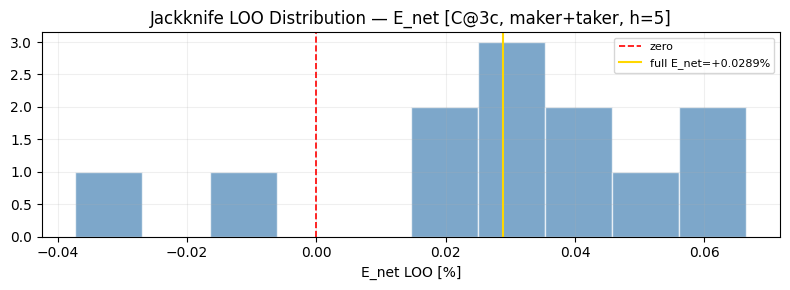

Cell 10 OK


In [9]:
# Jackknife LOO — Winner's Curse Control
print(SEP)
print('CELL 10 - JACKKNIFE LOO STABILITY (winner curse control)')
print(f'Low+Low selected from 9 bins after 08a. Upward bias in train E[ret] is expected.')
print(f'LOO stability criterion: P(E_net_LOO > 0) > {LOO_STABLE}')
print(SEP)

ret_col    = f'cont_{PRIMARY_H}c'
fc_primary = 'fill_C_3c'

if fc_primary not in sig_prim.columns:
    print('WARN: fill_C_3c not available — LOO skipped')
else:
    ra    = sig_prim[ret_col].values.astype(float)
    fa    = sig_prim[fc_primary].values.astype(bool)
    valid = ~np.isnan(ra)
    n     = len(ra)

    enet_loo = []
    drift_loo = []
    for i in range(n):
        mask   = np.ones(n, dtype=bool); mask[i] = False
        ra_loo = ra[mask]; fa_loo = fa[mask]; vl = valid[mask]
        pf     = fa_loo.mean()
        rf     = ra_loo[fa_loo & vl]
        if len(rf) == 0: continue
        enet_loo.append(rf.mean() * pf - NET_COST_MT)
        drift_loo.append(rf.mean() * pf)

    enet_loo  = np.array(enet_loo)
    drift_loo = np.array(drift_loo)

    p_loo_pos  = (enet_loo > 0).mean()
    print(f'\n  n = {n}  |  LOO samples = {len(enet_loo)}')
    print(f'  E_net LOO:  min={enet_loo.min()*100:+.5f}%  '
          f'median={np.median(enet_loo)*100:+.5f}%  max={enet_loo.max()*100:+.5f}%')
    print(f'  P(E_net_LOO > 0): {p_loo_pos*100:.1f}%  (threshold: {LOO_STABLE*100:.0f}%)')

    if p_loo_pos >= LOO_STABLE:
        loo_verdict = f'STABLE — removing any single event does not flip sign ({p_loo_pos*100:.0f}% > {LOO_STABLE*100:.0f}%)'
    elif p_loo_pos >= 0.50:
        loo_verdict = (f'FRAGILE — removing some events flips sign ({p_loo_pos*100:.0f}%). '
                       f'Edge depends on a small number of events')
    else:
        loo_verdict = f'VERY FRAGILE — majority of LOO removals give E_net <= 0 ({p_loo_pos*100:.0f}%)'

    print(f'  LOO verdict: {loo_verdict}')

    # Find influential events
    print(f'\n  Influential events (largest impact on E_net_LOO):')
    full_enet = ra[fa & valid].mean() * fa.mean() - NET_COST_MT if fa.mean() > 0 and (fa & valid).sum() > 0 else np.nan
    influence = full_enet - enet_loo  # positive = removing this event REDUCES E_net
    top_k = min(3, len(influence))
    top_idx = np.argsort(influence)[::-1][:top_k]
    for rank, idx in enumerate(top_idx, 1):
        print(f'  Rank {rank}: event {idx}  influence={influence[idx]*100:+.5f}%  '
              f'(if removed: E_net_LOO={enet_loo[idx]*100:+.5f}%)')

    # Plot LOO distribution
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(enet_loo * 100, bins=min(10, len(enet_loo)), color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', ls='--', lw=1.2, label='zero')
    if not np.isnan(full_enet):
        ax.axvline(full_enet * 100, color='gold', ls='-', lw=1.5, label=f'full E_net={full_enet*100:+.4f}%')
    ax.set_title(f'Jackknife LOO Distribution — E_net [C@3c, maker+taker, h={PRIMARY_H}]')
    ax.set_xlabel('E_net LOO [%]'); ax.legend(fontsize=8); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / '09b_jackknife_loo.png', dpi=100, bbox_inches='tight')
    plt.show()

print('Cell 10 OK')


CELL 11 - CONDITIONAL PATH SHAPE  (h=0 to 10)
Expected if inventory-transfer: dip at h=1-2, stabilize h=3-4, recover h=5+
Random walk: path oscillates around 0 without systematic shape

  Signals in path analysis: 12
     h    avg_cont(%)         SEM     avg+SEM     avg-SEM  Pattern
     1      +0.02007%   +0.03404%   +0.05411%   -0.01397%  
     2      +0.00909%   +0.04593%   +0.05503%   -0.03684%  
     3      -0.04400%   +0.04400%   +0.00001%   -0.08800%  stabilization
     4      -0.00232%   +0.05468%   +0.05236%   -0.05700%  stabilization
     5      +0.05647%   +0.08748%   +0.14395%   -0.03101%  
     6      +0.05091%   +0.06630%   +0.11721%   -0.01539%  
     7      +0.00671%   +0.05966%   +0.06637%   -0.05295%  
     8      +0.00962%   +0.13521%   +0.14483%   -0.12559%  
     9      +0.05357%   +0.14360%   +0.19717%   -0.09004%  
    10      +0.06093%   +0.12558%   +0.18651%   -0.06465%  

  PATH SHAPE: FLAT/NOISY. No systematic trajectory. Random walk cannot be ruled out.


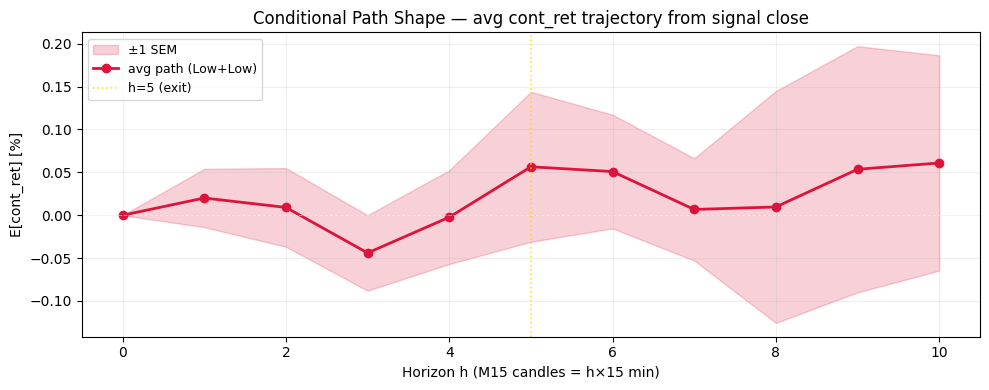

Cell 11 OK


In [10]:
# Conditional Path Shape — dip → absorption → continuation?
print(SEP)
print('CELL 11 - CONDITIONAL PATH SHAPE  (h=0 to 10)')
print('Expected if inventory-transfer: dip at h=1-2, stabilize h=3-4, recover h=5+')
print('Random walk: path oscillates around 0 without systematic shape')
print(SEP)

# Build path matrix: each row = one signal event, cols = cont_1c..cont_10c
path_cols = [f'cont_{h}c' for h in range(1, PATH_H + 1) if f'cont_{h}c' in sig_prim.columns]
h_vals    = [int(c.replace('cont_','').replace('c','')) for c in path_cols]

path_mat = sig_prim[path_cols].values.astype(float)  # shape (n_signals, PATH_H)

avg_path = np.nanmean(path_mat, axis=0)
sem_path = np.nanstd(path_mat, axis=0) / np.sqrt(np.maximum(np.sum(~np.isnan(path_mat), axis=0), 1))

print(f'\n  Signals in path analysis: {len(sig_prim)}')
print(f'  {"h":>4}  {"avg_cont(%)":>13}  {"SEM":>10}  {"avg+SEM":>10}  {"avg-SEM":>10}  Pattern')
for i, h in enumerate(h_vals):
    avg = avg_path[i]
    sem = sem_path[i]
    if np.isnan(avg): continue
    pattern = ''
    if   h <= 2  and avg < -0.01: pattern = 'dip (pullback fills maker)'
    elif h <= 2  and avg > 0.01:  pattern = 'no pullback — burst continues'
    elif 3 <= h <= 4 and abs(avg) < 0.02: pattern = 'stabilization'
    elif h >= 5  and avg > 0.01:  pattern = 'continuation (edge)'
    elif h >= 5  and avg < -0.01: pattern = 'continued fade'
    print(f'  {h:>4}  {avg*100:>+12.5f}%  {sem*100:>+9.5f}%  '
          f'{(avg+sem)*100:>+9.5f}%  {(avg-sem)*100:>+9.5f}%  {pattern}')

# Shape classification
dip_h1    = avg_path[h_vals.index(1)] if 1 in h_vals else np.nan
rec_h5    = avg_path[h_vals.index(PRIMARY_H)] if PRIMARY_H in h_vals else np.nan
dip_exists = (not np.isnan(dip_h1)) and dip_h1 < -0.005
rec_exists = (not np.isnan(rec_h5)) and rec_h5 > dip_h1 + 0.005

print()
if dip_exists and rec_exists:
    print(f'  PATH SHAPE: DIP-RECOVERY confirmed (h=1 dip={dip_h1*100:+.4f}% -> h=5 recovery={rec_h5*100:+.4f}%)')
    print('  Consistent with: maker fills during pullback, inventory transfer drives recovery')
elif not dip_exists and rec_exists:
    print(f'  PATH SHAPE: NO DIP, but RECOVERY at h=5. Maker fill mechanism unclear.')
elif dip_exists and not rec_exists:
    print(f'  PATH SHAPE: DIP exists but NO RECOVERY. Fade/reversal dominant. Maker long = wrong side.')
else:
    print(f'  PATH SHAPE: FLAT/NOISY. No systematic trajectory. Random walk cannot be ruled out.')

# Plot
h_plot = [0] + h_vals
avg_plot = [0.0] + list(avg_path)
sem_plot = [0.0] + list(sem_path)
avg_plot_a = np.array(avg_plot) * 100
sem_plot_a = np.array(sem_plot) * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(h_plot, avg_plot_a - sem_plot_a, avg_plot_a + sem_plot_a,
                alpha=0.2, color='crimson', label='±1 SEM')
ax.plot(h_plot, avg_plot_a, 'o-', color='crimson', lw=2, label='avg path (Low+Low)')
ax.axhline(0, color='white', ls='--', lw=0.7, alpha=0.5)
ax.axvline(PRIMARY_H, color='gold', ls=':', lw=1.2, alpha=0.8, label=f'h={PRIMARY_H} (exit)')
ax.set_title('Conditional Path Shape — avg cont_ret trajectory from signal close')
ax.set_xlabel('Horizon h (M15 candles = h×15 min)')
ax.set_ylabel('E[cont_ret] [%]')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09b_path_shape.png', dpi=100, bbox_inches='tight')
plt.show()
print('Cell 11 OK')


In [11]:
# Monthly breakdown
print(SEP)
print('CELL 12 - MONTHLY BREAKDOWN (holdout period only)')
print('Note: holdout ≈ 2 months. Per-month n will be 1-8 events. Advisory only.')
print(SEP)

ret_col    = f'cont_{PRIMARY_H}c'
fc_primary = 'fill_C_3c'

sig_prim['month'] = pd.to_datetime(sig_prim['open_time']).dt.to_period('M')
months = sorted(sig_prim['month'].unique())

print(f'\n  Months: {[str(m) for m in months]}  |  total n={len(sig_prim)}')
print(f'  {"Month":<10}  {"n":>4}  {"P(cont@5c)":>12}  {"drift@5c%":>12}  '
      f'{"P(fill,C@3c)":>14}  {"E_net(pt)%":>12}  Sign')

n_pos_months = 0
for month in months:
    mask = sig_prim['month'] == month
    grp  = sig_prim[mask]
    n    = len(grp)
    if n == 0: continue
    pc5  = (grp[ret_col].dropna() > 0).mean() * 100
    d5   = grp[ret_col].mean() * 100
    if fc_primary in grp.columns and grp[fc_primary].sum() > 0:
        pf   = grp[fc_primary].mean() * 100
        ef   = grp.loc[grp[fc_primary].astype(bool), ret_col].mean()
        en   = (ef * grp[fc_primary].mean() - NET_COST_MT) * 100
        sign = '+' if en > 0 else '-'
        if en > 0: n_pos_months += 1
    else:
        pf = np.nan; en = np.nan; sign = '?'
    pf_s = f'{pf:.0f}%' if not np.isnan(pf) else '--'
    en_s = f'{en:+.4f}%' if not np.isnan(en) else '--'
    print(f'  {str(month):<10}  {n:>4}  {pc5:>11.1f}%  {d5:>+11.5f}%  {pf_s:>14}  {en_s:>12}  {sign}')

print()
print(f'  Positive E_net months: {n_pos_months}/{len(months)}  (advisory — per-month n too small for conclusions)')
print('Cell 12 OK')


CELL 12 - MONTHLY BREAKDOWN (holdout period only)
Note: holdout ≈ 2 months. Per-month n will be 1-8 events. Advisory only.

  Months: ['2026-04', '2026-05']  |  total n=12
  Month          n    P(cont@5c)     drift@5c%    P(fill,C@3c)    E_net(pt)%  Sign
  2026-04        8         50.0%     +0.05245%            100%      +0.0324%  +
  2026-05        4         75.0%     +0.06452%             75%      +0.0219%  +

  Positive E_net months: 2/2  (advisory — per-month n too small for conclusions)
Cell 12 OK


In [12]:
# Final Verdict
SEP2 = '=' * 70
print(SEP2)
print('  EXP 09b - M15 EXECUTION FEASIBILITY — FINAL VERDICT')
print(f'  SPEC_HASH: {SPEC_HASH}')
print(f'  Prior: Exp09a-{REF_09A["spec_hash"]}')
print(f'  Thresholds: ATR={ATR_THRESH_M15:.4f}  EER_LOW={EER_LOW_M15:.4f}  [FROZEN]')
print(f'  n_holdout Low+Low = {len(sig_prim)}  |  h={PRIMARY_H} ({PRIMARY_H*15} min)')
print(SEP2)

ret_col    = f'cont_{PRIMARY_H}c'
fc_primary = 'fill_C_3c'

# Aggregate evidence
pk_enet = 'C@3c_maker+taker'
enet_go = enet_results.get(pk_enet, {}).get('all_go', False)
enet_pos = enet_results.get(pk_enet, {}).get('any_pos', False)

# LOO stability
loo_stable_flag = False
if fc_primary in sig_prim.columns:
    ra    = sig_prim[ret_col].values.astype(float)
    fa    = sig_prim[fc_primary].values.astype(bool)
    valid = ~np.isnan(ra)
    loo   = []
    for i in range(len(ra)):
        mask = np.ones(len(ra), dtype=bool); mask[i] = False
        rf   = ra[mask][fa[mask] & valid[mask]]
        pf   = fa[mask].mean()
        if len(rf) > 0: loo.append(rf.mean() * pf - NET_COST_MT)
    if len(loo) > 0:
        loo_stable_flag = (np.array(loo) > 0).mean() >= LOO_STABLE

# FQR check
fqr_c3 = fqr_results.get('C@3c', {}).get('fqr', np.nan)
fqr_ok = (not np.isnan(fqr_c3)) and fqr_c3 >= FQR_GO

# Print scorecard
print()
print('  ── SCORECARD ──')
print(f'  E_net[C@3c, mk+tk] > 0:          {"PASS" if enet_pos else "FAIL"}')
print(f'  CI_lower > 0 (all block sizes):   {"PASS" if enet_go else "FAIL (wide CI or negative)"}')
print(f'  LOO stability P>={LOO_STABLE}:         {"PASS" if loo_stable_flag else "FAIL (fragile edge)"}')
print(f'  FQR_C@3c >= {FQR_GO}:               {"PASS (FQR="+str(round(fqr_c3,3))+")" if fqr_ok else "FAIL"}')
print()

n_pass = sum([enet_pos, enet_go, loo_stable_flag, fqr_ok])

# Verdict
if enet_go and loo_stable_flag and fqr_ok:
    verdict = 'GO -> Exp09b.1: Expand data (2-4 years M1) to confirm with n_holdout >= 100'
    detail  = ['All criteria pass including CI lower bound and LOO stability',
               'Do NOT proceed to live trading with current n — need data expansion first',
               'Exp09b.1: same thresholds, same logic, 2-4yr historical M1']
elif enet_pos and not enet_go:
    verdict = 'INCONCLUSIVE -> Exp09b.1: Data Expansion Required'
    detail  = [f'E_net point estimate > 0 but CI crosses zero (expected with n={len(sig_prim)})',
               'This is NOT a NO-GO. The mechanism is promising but statistically unresolved.',
               'Priority: download 2-4 years M1 (2022-2026) -> resample M15 -> rerun 09b',
               f'Target: n_holdout Low+Low >= 50 (currently {len(sig_prim)})']
elif n_pass >= 2 and not enet_pos:
    verdict = 'NO-GO -> E_net <= 0 in holdout. Mechanism does not generalize OOS.'
    detail  = ['Point estimate negative or zero — signal did not survive holdout',
               'Bounded Claim update: {OHLCV, M1+M15, EER=Low+Low} -> directional alpha ~= 0',
               'Open paths: H1/H4 native hypotheses, L2 book data, OI/liquidation mechanics']
else:
    verdict = f'NO-GO ({n_pass}/4 criteria pass)'
    detail  = ['Insufficient evidence across the required criteria',
               'Review individual gate outputs above for root cause']

print(f'  VERDICT: {verdict}')
print()
for d in detail:
    print(f'    - {d}')

print()
print('  ── BOUNDED CLAIM STATUS ──')
print('  Proven: {OHLCV, M1, all families, retail taker+maker} -> alpha ~= 0')
if enet_pos:
    print('  Candidate: {OHLCV, M15, EER=Low+Vol=Low, maker} -> E_net > 0  [OOS positive, needs n expansion]')
else:
    print('  Closed: {OHLCV, M15, EER=Low+Vol=Low} -> alpha ~= 0')
    print('  Open: {H1/H4 OHLCV}  {L2 book}  {OI/liquidation mechanics}')

print()
print(SEP2)
print('Cell 13 OK - Exp09b complete')


  EXP 09b - M15 EXECUTION FEASIBILITY — FINAL VERDICT
  SPEC_HASH: c40753cfb893
  Prior: Exp09a-89f1a4e54b3a
  Thresholds: ATR=1.7027  EER_LOW=0.4167  [FROZEN]
  n_holdout Low+Low = 12  |  h=5 (75 min)

  ── SCORECARD ──
  E_net[C@3c, mk+tk] > 0:          PASS
  CI_lower > 0 (all block sizes):   FAIL (wide CI or negative)
  LOO stability P>=0.7:         PASS
  FQR_C@3c >= 0.7:               PASS (FQR=0.945)

  VERDICT: INCONCLUSIVE -> Exp09b.1: Data Expansion Required

    - E_net point estimate > 0 but CI crosses zero (expected with n=12)
    - This is NOT a NO-GO. The mechanism is promising but statistically unresolved.
    - Priority: download 2-4 years M1 (2022-2026) -> resample M15 -> rerun 09b
    - Target: n_holdout Low+Low >= 50 (currently 12)

  ── BOUNDED CLAIM STATUS ──
  Proven: {OHLCV, M1, all families, retail taker+maker} -> alpha ~= 0
  Candidate: {OHLCV, M15, EER=Low+Vol=Low, maker} -> E_net > 0  [OOS positive, needs n expansion]

Cell 13 OK - Exp09b complete
